# Inspect Raw VLS

Quick inspection notebook for VLS data using utilities from [analysis/scripts/data_loading.py](../scripts/data_loading.py) and [analysis/scripts/experiment_data.py](../scripts/experiment_data.py).

This notebook supports two loaders:
- Combined H5 via `load_data(...)`
- Raw FLASH H5 via `load_raw_h5(...)`

In [1]:
import os
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

os.environ.setdefault('FLASH_ENV', 'local')

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')

sys.path.insert(0, str(repo_root / 'analysis' / 'scripts'))

import config as path_config
from data_loading import load_data, load_raw_h5, ExperimentData

## Config

In [37]:
# Raw-only simplified workflow for single-energy inspection.
CONFIG = 2
RUN_NO = 58813

RAW_DIR = Path(path_config.RAW_H5_DIR)
TRAIN_LENGTH = 110
N_VLS_PIXELS = 1280
MAX_FILES = None

# Same settings as xas_static configs/scripts.
CROP_ROI = (450, 650)
SIGNAL_BUNCH_RANGE = (2, 102)
VLS_BUNCH_ROLL = 0

print(f'raw dir           : {RAW_DIR}')
print(f'run               : {RUN_NO}')
print(f'train length      : {TRAIN_LENGTH}')
print(f'max files         : {MAX_FILES}')
print(f'crop roi          : {CROP_ROI}')
print(f'signal bunch range: {SIGNAL_BUNCH_RANGE}')
print(f'bg bunch range    : {BG_BUNCH_RANGE}')
print(f'vls bunch roll    : {VLS_BUNCH_ROLL}')

raw dir           : /home/kaiyu/glycine26/11022188/raw/hdf/online-0/fl2user1
run               : 58813
train length      : 110
max files         : None
crop roi          : (450, 650)
signal bunch range: (2, 102)
bg bunch range    : (50, 100)
vls bunch roll    : 0


## Load Raw Dataset (train x bunch x pixel)

In [38]:
data = load_raw_h5(
    run_no=RUN_NO,
    config=CONFIG,
    raw_dir=RAW_DIR,
    train_length=TRAIN_LENGTH,
    n_vls_pixels=N_VLS_PIXELS,
    max_files=MAX_FILES,
)

if not isinstance(data, ExperimentData):
    raise TypeError('Expected ExperimentData from data_loading.load_raw_h5.')

# Mirror xas_static preprocessing: crop, optional bunch roll, trainwise background subtraction, then keep signal bunches.
data_xas = (
    data
    .crop_vls(*CROP_ROI)
    .roll_vls_bunches(VLS_BUNCH_ROLL)
    .trim_bunches(*SIGNAL_BUNCH_RANGE)
)

print('source mode: raw')
print(f'config         : {data.config}')
print(f'n_trains       : {data.n_trains}')
print(f'n_bunches raw  : {data.n_bunches}')
print(f'raw vls shape  : {data.vls.shape if data.vls is not None else None}')
print(f'xas vls shape  : {data_xas.vls.shape if data_xas.vls is not None else None}')
print(f'xas pixels     : {int(data_xas.vls_pixels[0])} .. {int(data_xas.vls_pixels[-1])}')
print(f'signal bunches : {SIGNAL_BUNCH_RANGE} -> {data_xas.n_bunches} bunches kept')

Loading 16 raw H5 file(s) for run 58813 (config 2).
  reading FLASH2_USER1_main_run58813_file1_20260605T143136.1.h5
  reading FLASH2_USER1_main_run58813_file2_20260605T143233.1.h5
  reading FLASH2_USER1_main_run58813_file3_20260605T143319.1.h5
  reading FLASH2_USER1_main_run58813_file4_20260605T143404.1.h5
  reading FLASH2_USER1_main_run58813_file5_20260605T143449.1.h5
  reading FLASH2_USER1_main_run58813_file6_20260605T143533.1.h5
  reading FLASH2_USER1_main_run58813_file7_20260605T143619.1.h5
  reading FLASH2_USER1_main_run58813_file8_20260605T143704.1.h5
  reading FLASH2_USER1_main_run58813_file9_20260605T143749.1.h5
  reading FLASH2_USER1_main_run58813_file10_20260605T143834.1.h5
  reading FLASH2_USER1_main_run58813_file11_20260605T143919.1.h5
  reading FLASH2_USER1_main_run58813_file12_20260605T144005.1.h5
  reading FLASH2_USER1_main_run58813_file13_20260605T144049.1.h5
  reading FLASH2_USER1_main_run58813_file14_20260605T144132.1.h5
  reading FLASH2_USER1_main_run58813_file15_202

## XAS-Static Bunch-Region Quicklook

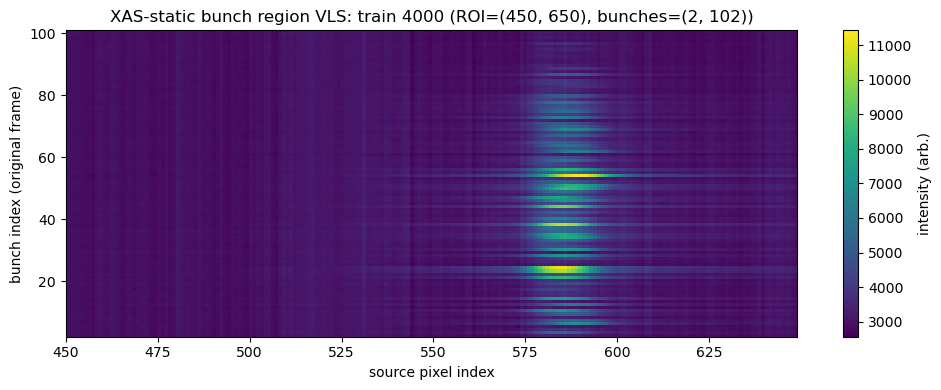

In [47]:
if data_xas.vls is None:
    raise RuntimeError('No VLS in this dataset. Use CONFIG=2.')

train_idx = 4000
vls_train = data_xas.vls[train_idx]  # (signal_bunches, n_pixels)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    vls_train,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    extent=[data_xas.vls_pixels[0], data_xas.vls_pixels[-1], SIGNAL_BUNCH_RANGE[0], SIGNAL_BUNCH_RANGE[1] - 1],
)
fig.colorbar(im, ax=ax, label='intensity (arb.)')
ax.set_title(
    f'XAS-static bunch region VLS: train {train_idx} '
    f'(ROI={CROP_ROI}, bunches={SIGNAL_BUNCH_RANGE})'
 )
ax.set_xlabel('source pixel index')
ax.set_ylabel('bunch index (original frame)')
fig.tight_layout()
plt.show()

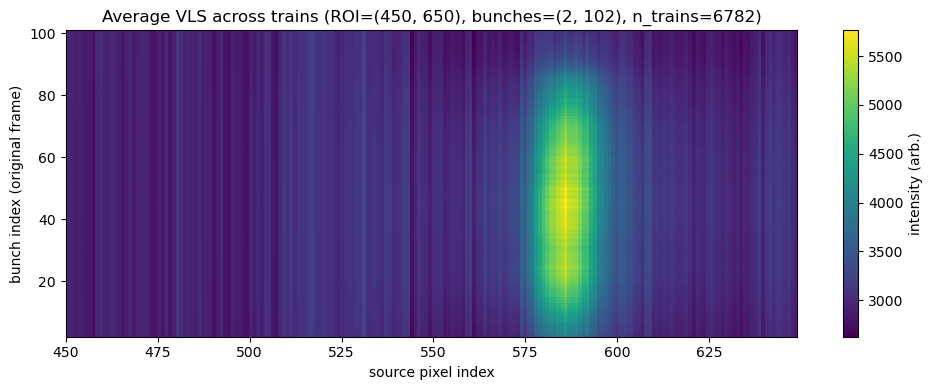

avg-over-trains shape: (100, 200)


In [40]:
if data_xas.vls is None:
    raise RuntimeError('No VLS in this dataset. Use CONFIG=2.')

# Average over trains first -> (signal_bunches, n_pixels).
vls_avg_over_trains = np.nanmean(data_xas.vls, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    vls_avg_over_trains,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    extent=[data_xas.vls_pixels[0], data_xas.vls_pixels[-1], SIGNAL_BUNCH_RANGE[0], SIGNAL_BUNCH_RANGE[1] - 1],
)
fig.colorbar(im, ax=ax, label='intensity (arb.)')
ax.set_title(
    f'Average VLS across trains '
    f'(ROI={CROP_ROI}, bunches={SIGNAL_BUNCH_RANGE}, n_trains={data_xas.n_trains})'
 )
ax.set_xlabel('source pixel index')
ax.set_ylabel('bunch index (original frame)')
fig.tight_layout()
plt.show()

print(f'avg-over-trains shape: {vls_avg_over_trains.shape}')

valid shots: 671418 / 678200


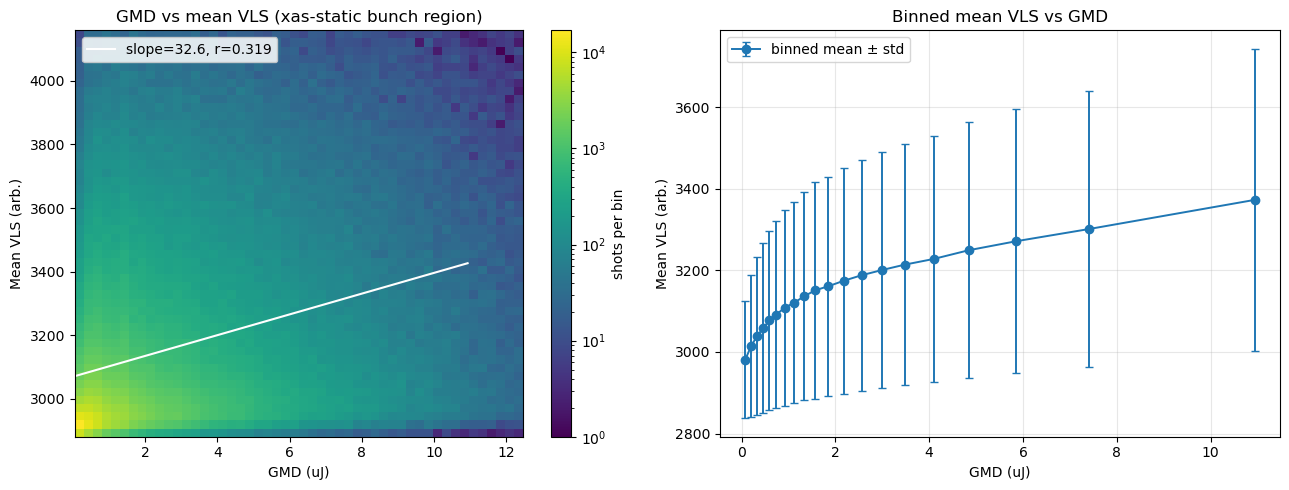

In [41]:
import matplotlib.colors as mcolors

if data_xas.vls is None:
    raise RuntimeError('No VLS in this dataset. Use CONFIG=2.')

# Per-shot arrays in the xas_static bunch region (train x bunch -> shots).
gmd_shots = data_xas.gmd.reshape(-1)
vls_mean_shots = np.nanmean(data_xas.vls, axis=2).reshape(-1)  # mean over pixels per shot

valid = np.isfinite(gmd_shots) & np.isfinite(vls_mean_shots)
x_gmd = gmd_shots[valid]
y_vls = vls_mean_shots[valid]

print(f'valid shots: {valid.sum()} / {valid.size}')

# Percentile-based binning like xas_static notebooks.
bin_edges = np.percentile(x_gmd, np.linspace(0, 100, 21))
bin_idx = np.clip(np.digitize(x_gmd, bin_edges) - 1, 0, len(bin_edges) - 2)
x_mean = np.array([np.nanmean(x_gmd[bin_idx == b]) if np.any(bin_idx == b) else np.nan
                   for b in range(len(bin_edges) - 1)])
y_mean = np.array([np.nanmean(y_vls[bin_idx == b]) if np.any(bin_idx == b) else np.nan
                   for b in range(len(bin_edges) - 1)])
y_std = np.array([np.nanstd(y_vls[bin_idx == b]) if np.any(bin_idx == b) else np.nan
                  for b in range(len(bin_edges) - 1)])

r = float(np.corrcoef(x_gmd, y_vls)[0, 1])
slope, intercept = np.polyfit(x_gmd, y_vls, 1)
xl = np.linspace(np.nanmin(x_mean), np.nanmax(x_mean), 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

h = ax1.hist2d(
    x_gmd,
    y_vls,
    bins=[np.linspace(np.percentile(x_gmd, 1), np.percentile(x_gmd, 99), 51),
          np.linspace(np.percentile(y_vls, 1), np.percentile(y_vls, 99), 51)],
    cmap='viridis',
    cmin=1,
    norm=mcolors.LogNorm(),
)
fig.colorbar(h[3], ax=ax1, label='shots per bin')
ax1.plot(xl, slope * xl + intercept, color='white', lw=1.5,
         label=f'slope={slope:.3g}, r={r:.3f}')
ax1.set_xlabel('GMD (uJ)')
ax1.set_ylabel('Mean VLS (arb.)')
ax1.set_title('GMD vs mean VLS (xas-static bunch region)')
ax1.legend(loc='upper left', framealpha=0.85)

ax2.errorbar(x_mean, y_mean, yerr=y_std, fmt='o-', color='tab:blue',
             capsize=3, lw=1.4, label='binned mean ± std')
ax2.set_xlabel('GMD (uJ)')
ax2.set_ylabel('Mean VLS (arb.)')
ax2.set_title('Binned mean VLS vs GMD')
ax2.grid(alpha=0.3)
ax2.legend()

fig.tight_layout()
plt.show()